In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Sobe de codigos/ para a raiz do projeto
BASE = Path.cwd().parent         
DADOS = BASE / "dados" / "brutos"
FIGURAS = BASE / "resultados" / "figuras"


#Objetivo aqui é transformar os dados de hiato de produto em um dataframe para melhor trabalhar com os dados

data_gap = pd.read_excel(DADOS/"gap.xlsx", header=2)
# Selecionamos apenas as colunas de interesse
df_gap = data_gap[["Quarterly", "Output gap"]]
#Eliminamos as linhas que não possuiam dados
df_gap = df_gap.drop([0,1])

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
gap_ano = df_gap[df_gap['Quarterly'].str.contains('4Q$', na = False)]

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)
gap_ano = gap_ano.set_index('Quarterly')
gap_ano.index.name = 'Year'

gap_ano.head()

C:\Users\tgu12\AppData\Local\Temp\ipykernel_17900\1590848062.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gap_ano['Quarterly'] = gap_ano['Quarterly'].str.replace(".4Q", '',regex=False).astype(int)


,Output gap
Year,
1983,-0.328574
1984,1.134027
1985,-0.191477
1986,-0.455183
1987,0.452045


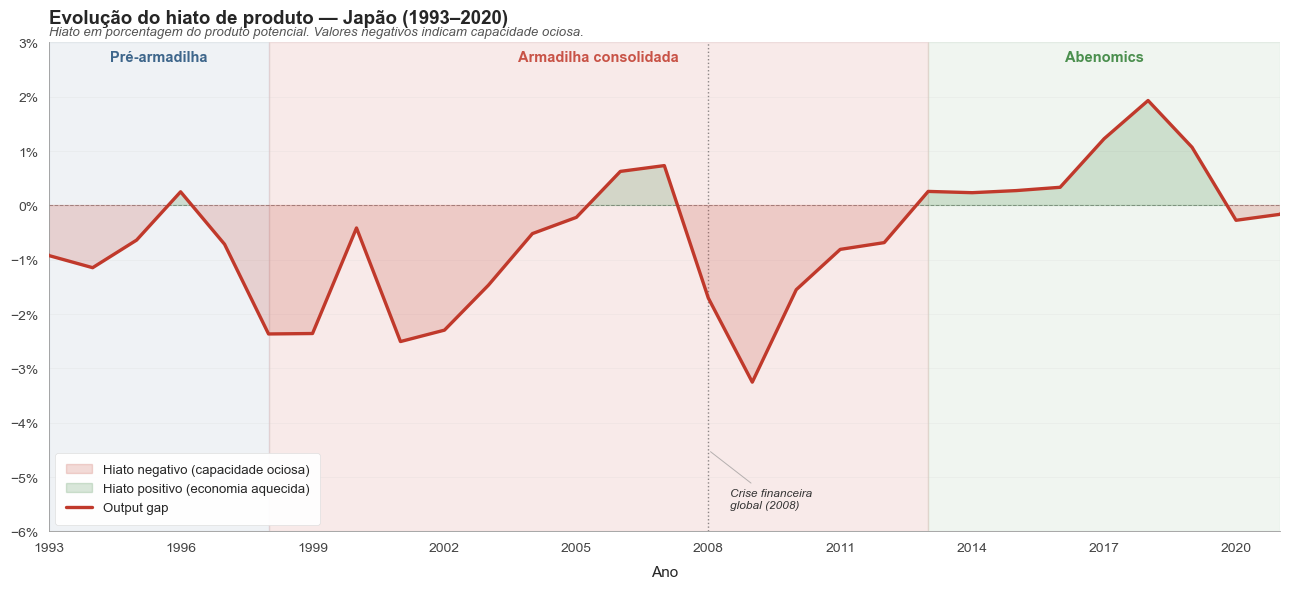

In [61]:
#Gráfico:
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Garante coluna Year e tipos numéricos limpos
gap_ano = gap_ano.reset_index() if 'Year' not in gap_ano.columns else gap_ano
gap_ano['Year'] = pd.to_numeric(gap_ano['Year'], errors='coerce').astype('Int64')
gap_ano['Output gap'] = pd.to_numeric(gap_ano['Output gap'], errors='coerce')
gap_ano = gap_ano.dropna(subset=['Year', 'Output gap']).copy()
gap_ano['Year'] = gap_ano['Year'].astype(int)


anos    = gap_ano['Year'].to_numpy(dtype=float)
valores = gap_ano['Output gap'].to_numpy(dtype=float)

COR_GAP      = '#c0392b'
COR_NEGATIVO = '#c0392b'
COR_POSITIVO = '#2e7d32'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color=COR_GAP,   zorder=0)
ax.axvspan(2013, 2021, alpha=0.07, color='#2e7d32', zorder=0)

ax.set_ylim(-6, 3)
ax.set_xlim(1993, 2021)

y_label = 2.65
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color='#1f4e79', weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color=COR_GAP, weight='bold', alpha=0.85)
ax.text(2017, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -4.5), xytext=(2008.5, -5.4),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# fill_between usando arrays numpy puros (não Series)
ax.fill_between(anos, valores, 0,
                where=(valores < 0),
                color=COR_NEGATIVO, alpha=0.18, interpolate=True, zorder=2,
                label='Hiato negativo (capacidade ociosa)')
ax.fill_between(anos, valores, 0,
                where=(valores >= 0),
                color=COR_POSITIVO, alpha=0.18, interpolate=True, zorder=2,
                label='Hiato positivo (economia aquecida)')

sns.lineplot(data=gap_ano, x='Year', y='Output gap',
             linewidth=2.4, color=COR_GAP, ax=ax, zorder=3,
             label='Output gap')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(range(1993, 2022, 3))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Evolução do hiato de produto — Japão (1993–2020)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'Hiato em porcentagem do produto potencial. Valores negativos indicam capacidade ociosa.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.tick_params(colors='#444', length=4, width=0.6)

plt.tight_layout()
plt.savefig(FIGURAS/'grafico_output_gap.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()



_Dividir a análise em duas:_


In [62]:


gap_ano = gap_ano.set_index('Year')
gap_ano.index.name = 'Year'


#Primeiro gráfico : de 1993 até 2000
gap_93_00 = gap_ano.loc[1993:2000]


#Segundo gráfico: 2000 até 2025
gap_00_19 = gap_ano.loc[2000:2019]
gap_93_00



,Output gap
Year,
1993,-0.920757
1994,-1.145398
1995,-0.637239
1996,0.251554
1997,-0.714214
1998,-2.364976
1999,-2.356900
2000,-0.414437


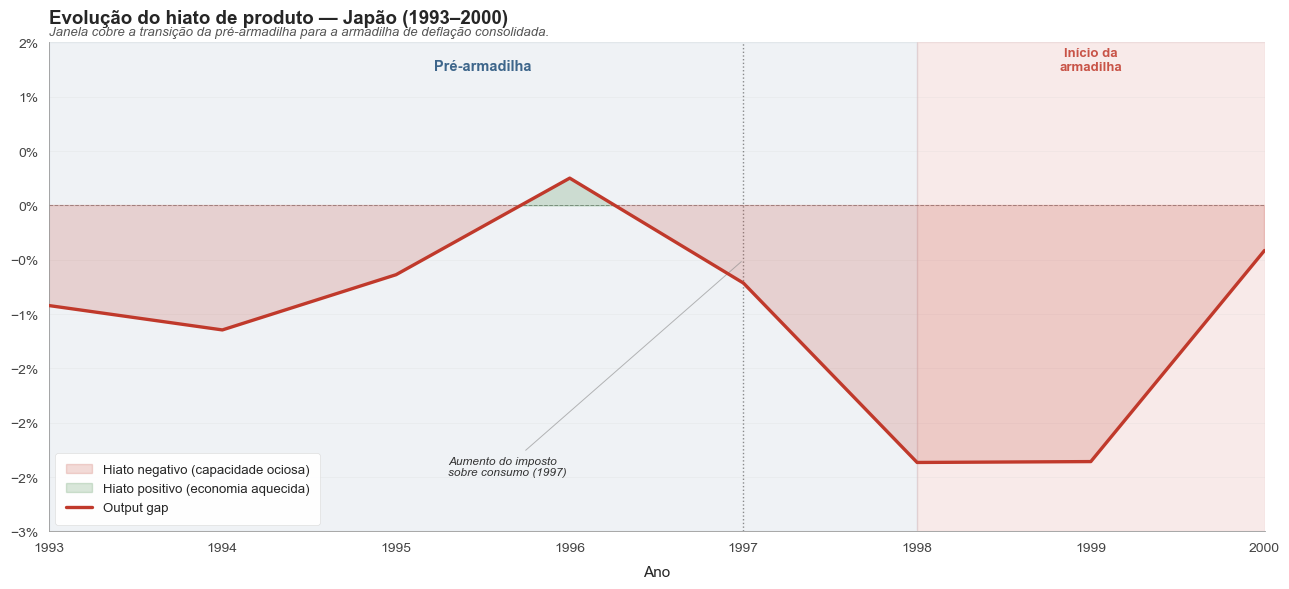

In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

gap_93_00 = gap_93_00.reset_index() if 'Year' not in gap_93_00.columns else gap_93_00
gap_93_00['Year'] = pd.to_numeric(gap_93_00['Year'], errors='coerce').astype('Int64')
gap_93_00['Output gap'] = pd.to_numeric(gap_93_00['Output gap'], errors='coerce')
gap_93_00 = gap_93_00.dropna(subset=['Year', 'Output gap']).copy()
gap_93_00['Year'] = gap_93_00['Year'].astype(int)
anos    = gap_93_00['Year'].to_numpy(dtype=float)
valores = gap_93_00['Output gap'].to_numpy(dtype=float)

COR_GAP      = '#c0392b'
COR_NEGATIVO = '#c0392b'
COR_POSITIVO = '#2e7d32'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

# Duas eras nessa janela: pré-armadilha (1993-1998) e início da armadilha (1998-2000)
ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2000, alpha=0.10, color=COR_GAP,   zorder=0)

ax.set_ylim(-3, 1.5)
ax.set_xlim(1993, 2000)

# Rótulos das eras
y_label = 1.25
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color='#1f4e79', weight='bold', alpha=0.85)
ax.text(1999, y_label, 'Início da\narmadilha',
        ha='center', fontsize=9.5, color=COR_GAP, weight='bold', alpha=0.85)

ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# Marcador do aumento do imposto sobre consumo (abril 1997)
ax.axvline(1997, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Aumento do imposto\nsobre consumo (1997)',
            xy=(1997, -0.5), xytext=(1995.3, -2.4),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# Preenchimento bicolor
ax.fill_between(anos, valores, 0,
                where=(valores < 0),
                color=COR_NEGATIVO, alpha=0.18, interpolate=True, zorder=2,
                label='Hiato negativo (capacidade ociosa)')
ax.fill_between(anos, valores, 0,
                where=(valores >= 0),
                color=COR_POSITIVO, alpha=0.18, interpolate=True, zorder=2,
                label='Hiato positivo (economia aquecida)')

# Linha principal
sns.lineplot(data=gap_93_00, x='Year', y='Output gap',
             linewidth=2.4, color=COR_GAP, ax=ax, zorder=3,
             label='Output gap')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(range(1993, 2001, 1))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Evolução do hiato de produto — Japão (1993–2000)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'Janela cobre a transição da pré-armadilha para a armadilha de deflação consolidada.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.tick_params(colors='#444', length=4, width=0.6)

plt.tight_layout()
plt.savefig(FIGURAS/'output_gap_93_00.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

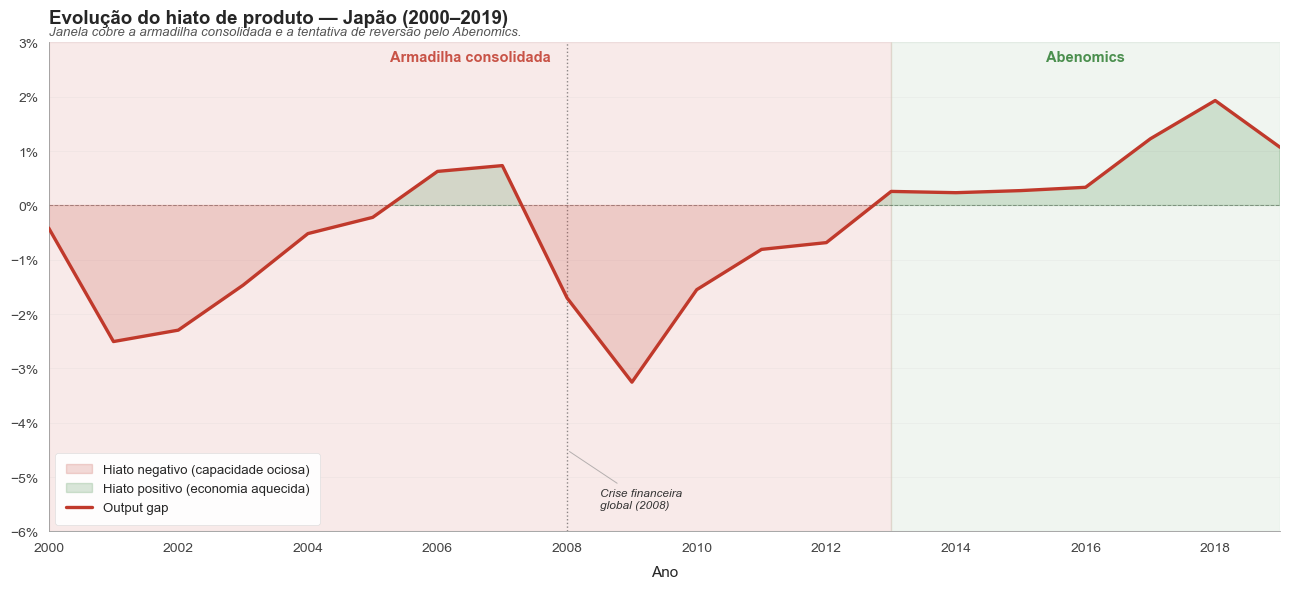

In [64]:
#Gráfico de 2000 - 2019
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

gap_00_19 = gap_00_19.reset_index() if 'Year' not in gap_00_19.columns else gap_00_19
gap_00_19['Year'] = pd.to_numeric(gap_00_19['Year'], errors='coerce').astype('Int64')
gap_00_19['Output gap'] = pd.to_numeric(gap_00_19['Output gap'], errors='coerce')
gap_00_19 = gap_00_19.dropna(subset=['Year', 'Output gap']).copy()
gap_00_19['Year'] = gap_00_19['Year'].astype(int)
anos    = gap_00_19['Year'].to_numpy(dtype=float)
valores = gap_00_19['Output gap'].to_numpy(dtype=float)

COR_GAP      = '#c0392b'
COR_NEGATIVO = '#c0392b'
COR_POSITIVO = '#2e7d32'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

# Duas eras nessa janela: armadilha consolidada (2000-2013) + Abenomics (2013-2019)
ax.axvspan(2000, 2013, alpha=0.10, color=COR_GAP,   zorder=0)
ax.axvspan(2013, 2019, alpha=0.07, color='#2e7d32', zorder=0)

ax.set_ylim(-6, 3)
ax.set_xlim(2000, 2019)

# Rótulos das eras
y_label = 2.65
ax.text(2006.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color=COR_GAP, weight='bold', alpha=0.85)
ax.text(2016, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# Crise financeira global (2008)
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -4.5), xytext=(2008.5, -5.4),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# Preenchimento bicolor
ax.fill_between(anos, valores, 0,
                where=(valores < 0),
                color=COR_NEGATIVO, alpha=0.18, interpolate=True, zorder=2,
                label='Hiato negativo (capacidade ociosa)')
ax.fill_between(anos, valores, 0,
                where=(valores >= 0),
                color=COR_POSITIVO, alpha=0.18, interpolate=True, zorder=2,
                label='Hiato positivo (economia aquecida)')

# Linha principal
sns.lineplot(data=gap_00_19, x='Year', y='Output gap',
             linewidth=2.4, color=COR_GAP, ax=ax, zorder=3,
             label='Output gap')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(range(2000, 2020, 2))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Evolução do hiato de produto — Japão (2000–2019)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'Janela cobre a armadilha consolidada e a tentativa de reversão pelo Abenomics.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.tick_params(colors='#444', length=4, width=0.6)

plt.tight_layout()
plt.savefig(FIGURAS/'output_gap_00_19.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

_TAXA DE JUROS NATURAL_

In [65]:
#Gráfico Baseado nas estimativas do modelo de Goy and Iwasaki (2024)

tx_juros = pd.read_excel(DADOS/"natural_interest_rate_japan.xlsx",header = 2)
tx_juros = tx_juros[["Unnamed: 2", "Goy and Iwasaki (2024)"]]

#Como nossa análise será pautada por ano, pegaremos apenas os resultados dos últimos trimestres
tx_n_y = tx_juros[tx_juros['Unnamed: 2'].str.contains('Q4$', na = False)]
tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)

#Agora transformaremos o Dataframe para que os anos sejam o novo índice:
# 1. Renomeia as colunas corretamente usando o método .rename()
tx_n_y = tx_n_y.rename(columns={
    'Unnamed: 2': 'Year',
    'Goy and Iwasaki (2024)': 'Natural interest rate'
})

# 2. Transforma os anos no novo índice do DataFrame
tx_n_y = tx_n_y.set_index('Year')


tx_n_y.tail(), tx_n_y.head()



C:\Users\tgu12\AppData\Local\Temp\ipykernel_17900\3011253932.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tx_n_y['Unnamed: 2'] = tx_n_y['Unnamed: 2'].str.replace("Q4", '',regex=False).astype(int)


(      Natural interest rate
 Year                       
 2020              -0.701056
 2021              -0.753173
 2022              -0.841298
 2023              -1.005236
 2024              -0.972300,
       Natural interest rate
 Year                       
 1992                    NaN
 1993               0.885443
 1994               0.677270
 1995               0.210731
 1996               0.044659)

_Plotando gráfico_

In [66]:
#Primeiro gráfico : de 1993 até 2000
tx_n_93_00 = tx_n_y.loc[1993:2000]
#Segundo gráfico: 2000 até 2023
tx_n_00_23 = tx_n_y.loc[2000:2023]


EVOLUÇÃO TAXA DE JUROS NATURAL DE 1993 - 2000


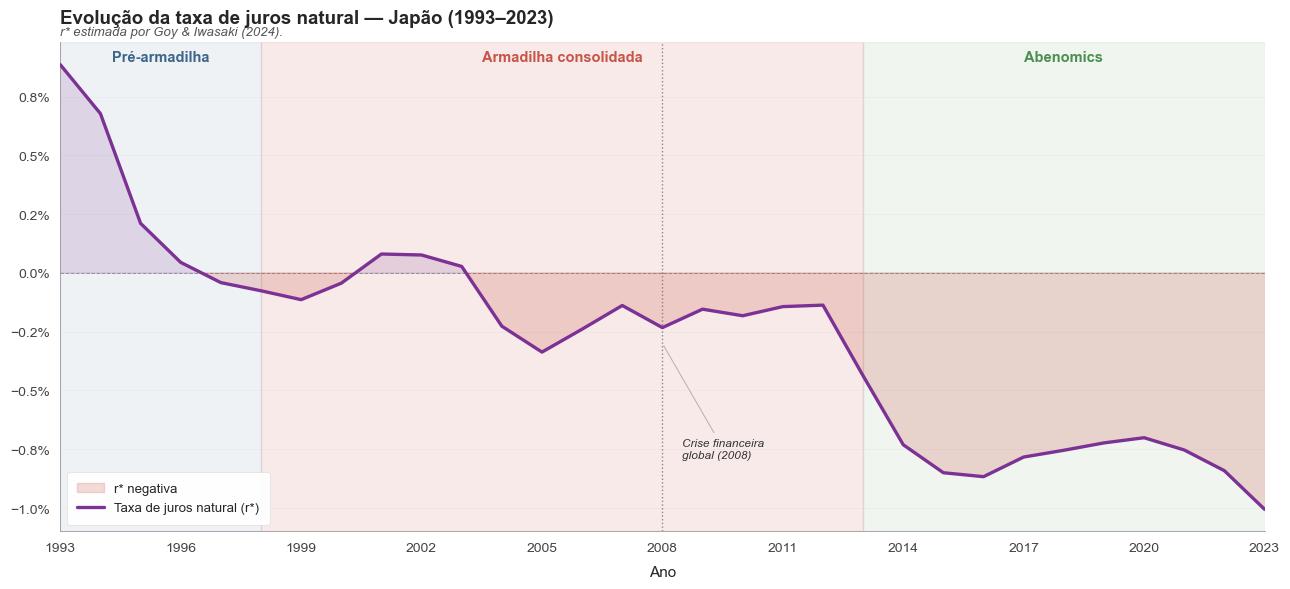

In [67]:
#Gráfico taxa de juros natural 1993 - 2023


sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

#Linha para caso o ano estiver como índice
tx_n_y = tx_n_y.reset_index() if 'Year' not in tx_n_y.columns else tx_n_y
tx_n_y['Year'] = tx_n_y['Year'].astype(int)

#Cores escolhidas
COR_NATURAL  = '#7b3294'
COR_POSITIVO = '#2e7d32'
COR_NEGATIVO = '#c0392b'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

# Sombreamento das três eras
ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2013, alpha=0.10, color='#c0392b', zorder=0)
ax.axvspan(2013, 2023, alpha=0.07, color='#2e7d32', zorder=0)

ax.set_xlim(1993, 2023)

# (set_ylim será definido depois de ver o range automático — deixar comentado
#  e ajustar se necessário)
# ax.set_ylim(-1, 2)

# Rótulos dos períodos
y_label = 0.9  # ajuste conforme o range da sua série
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color='#1f4e79', weight='bold', alpha=0.85)
ax.text(2005.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color='#c0392b', weight='bold', alpha=0.85)
ax.text(2018, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# Crise financeira global (2008)
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -0.3), xytext=(2008.5, -0.75),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# Preenchimento bicolor: roxo quando positiva, vermelho quando negativa
ax.fill_between(tx_n_y['Year'], tx_n_y['Natural interest rate'], 0,
                where=(tx_n_y['Natural interest rate'] >= 0),
                color=COR_NATURAL, alpha=0.15, interpolate=True, zorder=2)
ax.fill_between(tx_n_y['Year'], tx_n_y['Natural interest rate'], 0,
                where=(tx_n_y['Natural interest rate'] < 0),
                color=COR_NEGATIVO, alpha=0.18, interpolate=True, zorder=2,
                label='r* negativa')

# Linha principal
sns.lineplot(data=tx_n_y, x='Year', y='Natural interest rate',
             linewidth=2.4, color=COR_NATURAL, ax=ax, zorder=3,
             label='Taxa de juros natural (r*)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))

ax.set_xticks(range(1993, 2024, 3))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Evolução da taxa de juros natural — Japão (1993–2023)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'r* estimada por Goy & Iwasaki (2024).',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.tick_params(colors='#444', length=4, width=0.6)

plt.tight_layout()
plt.savefig(FIGURAS/'geral_natural_interest_rate.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

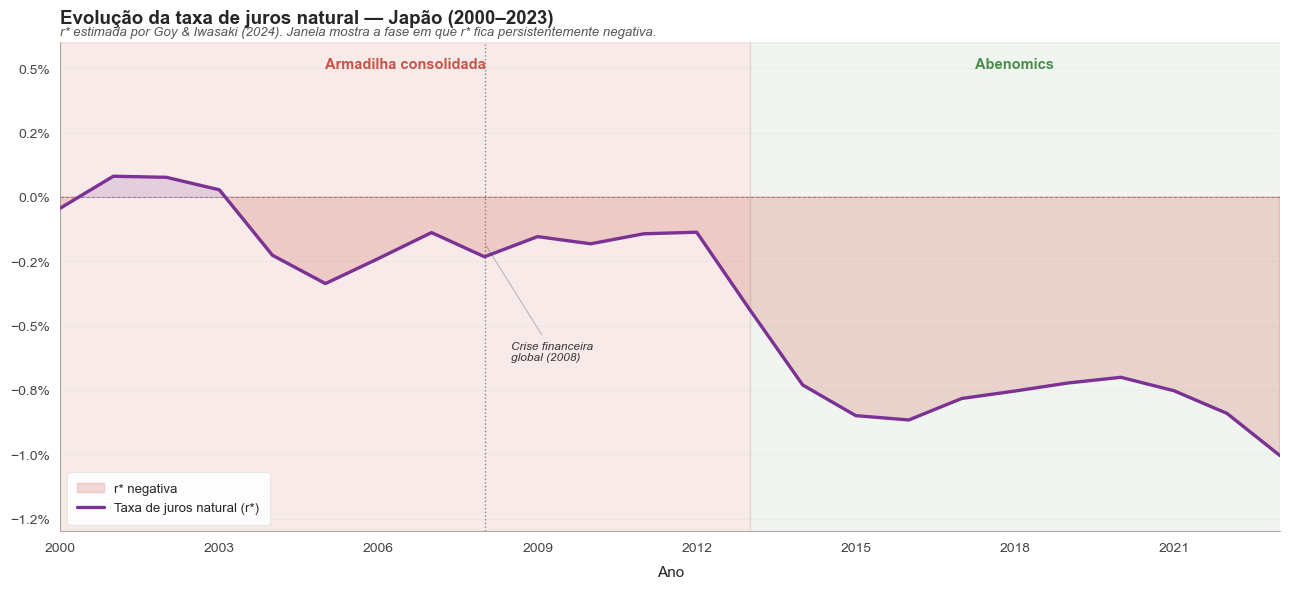

In [68]:
#Gráfico Taxa de juros natural 2000 - 2023
sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

tx_n_00_23 = tx_n_00_23.reset_index() if 'Year' not in tx_n_00_23.columns else tx_n_00_23
tx_n_00_23['Year'] = tx_n_00_23['Year'].astype(int)

COR_NATURAL  = '#7b3294'
COR_NEGATIVO = '#c0392b'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

# Apenas duas eras nessa janela (2000-2023): armadilha consolidada + Abenomics
ax.axvspan(2000, 2013, alpha=0.10, color='#c0392b', zorder=0)
ax.axvspan(2013, 2023, alpha=0.07, color='#2e7d32', zorder=0)

ax.set_xlim(2000, 2023)
ax.set_ylim(-1.3, 0.6)

# Rótulos das eras (dentro do range)
y_label = 0.5
ax.text(2006.5, y_label, 'Armadilha consolidada',
        ha='center', fontsize=10.5, color='#c0392b', weight='bold', alpha=0.85)
ax.text(2018, y_label, 'Abenomics',
        ha='center', fontsize=10.5, color='#2e7d32', weight='bold', alpha=0.85)

ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# Crise financeira global (2008)
ax.axvline(2008, color='#333', linewidth=1.0, linestyle=':', alpha=0.55, zorder=1)
ax.annotate('Crise financeira\nglobal (2008)',
            xy=(2008, -0.18), xytext=(2008.5, -0.6),
            fontsize=8.5, ha='left', va='center',
            color='#333', style='italic',
            arrowprops=dict(arrowstyle='-', color='#888', alpha=0.6, lw=0.7))

# Preenchimento bicolor: roxo quando positiva, vermelho quando negativa
ax.fill_between(tx_n_00_23['Year'], tx_n_00_23['Natural interest rate'], 0,
                where=(tx_n_00_23['Natural interest rate'] >= 0),
                color=COR_NATURAL, alpha=0.15, interpolate=True, zorder=2)
ax.fill_between(tx_n_00_23['Year'], tx_n_00_23['Natural interest rate'], 0,
                where=(tx_n_00_23['Natural interest rate'] < 0),
                color=COR_NEGATIVO, alpha=0.18, interpolate=True, zorder=2,
                label='r* negativa')

# Linha principal
sns.lineplot(data=tx_n_00_23, x='Year', y='Natural interest rate',
             linewidth=2.4, color=COR_NATURAL, ax=ax, zorder=3,
             label='Taxa de juros natural (r*)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_xticks(range(2000, 2024, 3))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Evolução da taxa de juros natural — Japão (2000–2023)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'r* estimada por Goy & Iwasaki (2024). Janela mostra a fase em que r* fica persistentemente negativa.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.tick_params(colors='#444', length=4, width=0.6)

plt.tight_layout()
plt.savefig(FIGURAS/'natural_interest_rate_00-23.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

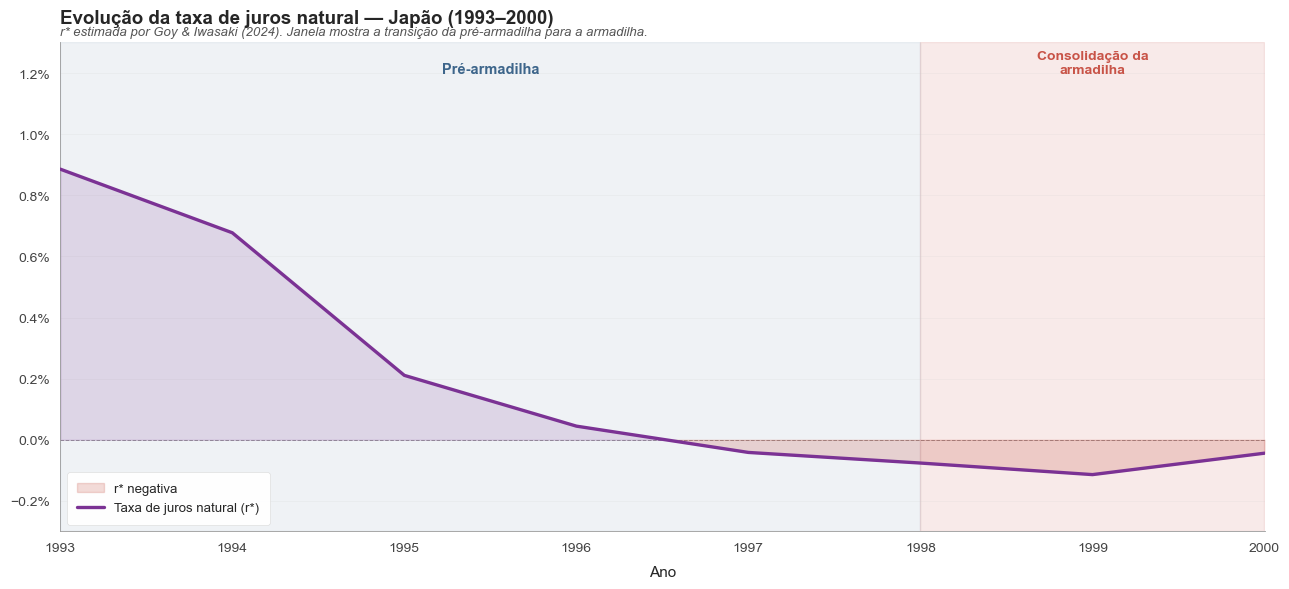

In [69]:
#Gráfico taxa de juros natural de 1993 - 2000

sns.set_style('white')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

tx_n_93_00 = tx_n_93_00.reset_index() if 'Year' not in tx_n_93_00.columns else tx_n_93_00
tx_n_93_00['Year'] = tx_n_93_00['Year'].astype(int)

COR_NATURAL  = '#7b3294'
COR_NEGATIVO = '#c0392b'

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')

# Apenas duas eras nessa janela (1993-2000):
# pré-armadilha (1993-1998) e início da armadilha consolidada (1998-2000)
ax.axvspan(1993, 1998, alpha=0.07, color='#1f4e79', zorder=0)
ax.axvspan(1998, 2000, alpha=0.10, color='#c0392b', zorder=0)

ax.set_xlim(1993, 2000)
ax.set_ylim(-0.3, 1.3)

# Rótulos das eras
y_label = 1.2
ax.text(1995.5, y_label, 'Pré-armadilha',
        ha='center', fontsize=10.5, color='#1f4e79', weight='bold', alpha=0.85)
ax.text(1999, y_label, 'Consolidação da\narmadilha',
        ha='center', fontsize=10, color='#c0392b', weight='bold', alpha=0.85)

ax.axhline(0, color='#333', linewidth=0.7, linestyle='--', alpha=0.45, zorder=1)

# Preenchimento bicolor: roxo quando positiva, vermelho quando negativa
ax.fill_between(tx_n_93_00['Year'], tx_n_93_00['Natural interest rate'], 0,
                where=(tx_n_93_00['Natural interest rate'] >= 0),
                color=COR_NATURAL, alpha=0.15, interpolate=True, zorder=2)
ax.fill_between(tx_n_93_00['Year'], tx_n_93_00['Natural interest rate'], 0,
                where=(tx_n_93_00['Natural interest rate'] < 0),
                color=COR_NEGATIVO, alpha=0.18, interpolate=True, zorder=2,
                label='r* negativa')

# Linha principal
sns.lineplot(data=tx_n_93_00, x='Year', y='Natural interest rate',
             linewidth=2.4, color=COR_NATURAL, ax=ax, zorder=3,
             label='Taxa de juros natural (r*)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_xticks(range(1993, 2001, 1))

ax.set_xlabel('Ano', fontsize=11, labelpad=8)
ax.set_ylabel('', fontsize=11)
ax.set_title('Evolução da taxa de juros natural — Japão (1993–2000)',
             fontsize=13.5, weight='bold', pad=14, loc='left')

ax.text(0.0, 1.015,
        'r* estimada por Goy & Iwasaki (2024). Janela mostra a transição da pré-armadilha para a armadilha.',
        transform=ax.transAxes, fontsize=9.5, style='italic',
        color='#555', ha='left')

legend = ax.legend(loc='lower left', framealpha=0.95, fontsize=9.5,
                   frameon=True, edgecolor='#ddd', borderpad=0.8)
legend.get_frame().set_linewidth(0.5)

ax.grid(axis='y', alpha=0.22, linewidth=0.5)
ax.grid(axis='x', visible=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_color('#999')
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.tick_params(colors='#444', length=4, width=0.6)

plt.tight_layout()
plt.savefig(FIGURAS/'natural_interest_rate_93-00.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()